#  Level 3 — Task 2: Support Vector Machine (SVM) for Classification
**Intern:** Amos Njama Mungai | **Company:** Codveda Technologies

**Dataset:** Churn Prediction Data

**Objectives:**
- Train an SVM model on a labeled dataset
- Use different kernels (linear, RBF) and compare performance
- Visualize the decision boundary
- Evaluate using accuracy, precision, recall, and AUC

**Tools:** Python, Scikit-learn, Pandas, Matplotlib

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')

Mounted at /content/drive
✅ Google Drive mounted successfully


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc
)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Step 3: Load the Dataset

In [3]:

churn_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive/Data Set For Task'):
    for file in files:
        if 'churn' in file.lower() and file.endswith('.csv'):
            churn_path = os.path.join(root, file)
            print(f'✅ Found: {churn_path}')

if churn_path is None:
    print('❌ Not found automatically. Listing all files:')
    for root, dirs, files in os.walk('/content/drive/MyDrive/Data Set For Task'):
        for file in files:
            print(os.path.join(root, file))

✅ Found: /content/drive/MyDrive/Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv
✅ Found: /content/drive/MyDrive/Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv


In [4]:
df = pd.read_csv(churn_path)
print('✅ Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully
Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False


## Step 4: Explore the Dataset

In [5]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== All Columns ===')
print(list(df.columns))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

## Step 5: Preprocess the Dataset

In [6]:
# Drop duplicates
df = df.drop_duplicates()

# Drop ID columns
id_cols = [c for c in df.columns if 'id' in c.lower()]
if id_cols:
    df = df.drop(columns=id_cols)
    print(f'Dropped: {id_cols}')

# Find target column (churn)
target_col = [c for c in df.columns if 'churn' in c.lower()]
TARGET = target_col[0] if target_col else df.columns[-1]
print(f'Target column: {TARGET}')
print(f'Class distribution:\n{df[TARGET].value_counts()}')

Target column: Churn
Class distribution:
Churn
False    2278
True      388
Name: count, dtype: int64


In [7]:
# Fill missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Encode categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'✅ Preprocessing complete — Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')

✅ Preprocessing complete — Shape: (2666, 20)
Missing values: 0


In [8]:
# Define features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 2132
Testing samples  : 534


## Step 6: Train SVM with Different Kernels

In [9]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42, probability=True)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')

    results.append({'Kernel': kernel, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f'Kernel: {kernel:<8} | Accuracy: {acc*100:.2f}% | F1: {f1*100:.2f}%')

results_df = pd.DataFrame(results)
print('\n=== Kernel Comparison ===')
print(results_df.round(4).to_string(index=False))

Kernel: linear   | Accuracy: 85.39% | F1: 78.67%
Kernel: rbf      | Accuracy: 89.89% | F1: 88.46%
Kernel: poly     | Accuracy: 89.33% | F1: 87.65%
Kernel: sigmoid  | Accuracy: 79.59% | F1: 77.39%

=== Kernel Comparison ===
 Kernel  Accuracy  Precision  Recall  F1-Score
 linear    0.8539     0.7292  0.8539    0.7867
    rbf    0.8989     0.8913  0.8989    0.8846
   poly    0.8933     0.8842  0.8933    0.8765
sigmoid    0.7959     0.7561  0.7959    0.7739


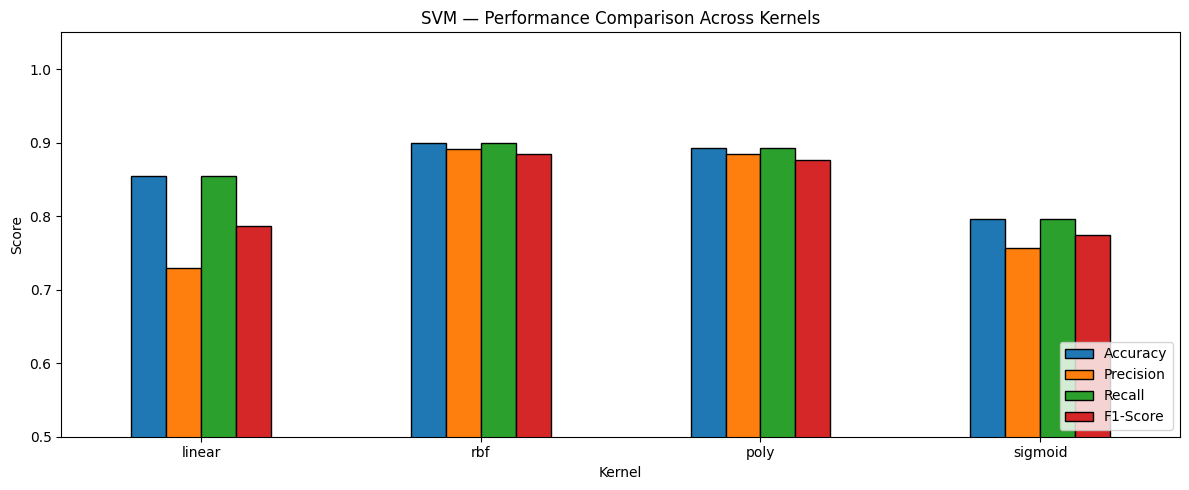


✅ Best Kernel = rbf


In [10]:
# Plot kernel comparison
results_df.set_index('Kernel')[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', figsize=(12, 5), edgecolor='black'
)
plt.title('SVM — Performance Comparison Across Kernels')
plt.ylabel('Score')
plt.xlabel('Kernel')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_kernel = results_df.loc[results_df['Accuracy'].idxmax(), 'Kernel']
print(f'\n✅ Best Kernel = {best_kernel}')

## Step 7: Train Final SVM with Best Kernel

In [11]:
svm_best = SVC(kernel=best_kernel, random_state=42, probability=True)
svm_best.fit(X_train, y_train)
y_pred_best = svm_best.predict(X_test)
y_prob_best = svm_best.predict_proba(X_test)[:, 1]

print(f'✅ Final SVM trained with kernel = {best_kernel}')

✅ Final SVM trained with kernel = rbf


## Step 8: Evaluate the Model

In [12]:
accuracy  = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred_best, average='weighted')
f1        = f1_score(y_test, y_pred_best, average='weighted')
auc_score = roc_auc_score(y_test, y_prob_best)

print('=======================================')
print(f'   MODEL EVALUATION (Kernel={best_kernel})')
print('=======================================')
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  AUC       : {auc_score:.4f}')
print('=======================================')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_best))

   MODEL EVALUATION (Kernel=rbf)
  Accuracy  : 89.89%
  Precision : 89.13%
  Recall    : 89.89%
  F1-Score  : 88.46%
  AUC       : 0.8591

=== Classification Report ===
              precision    recall  f1-score   support

       False       0.91      0.98      0.94       456
        True       0.80      0.41      0.54        78

    accuracy                           0.90       534
   macro avg       0.85      0.70      0.74       534
weighted avg       0.89      0.90      0.88       534



## Step 9: Confusion Matrix

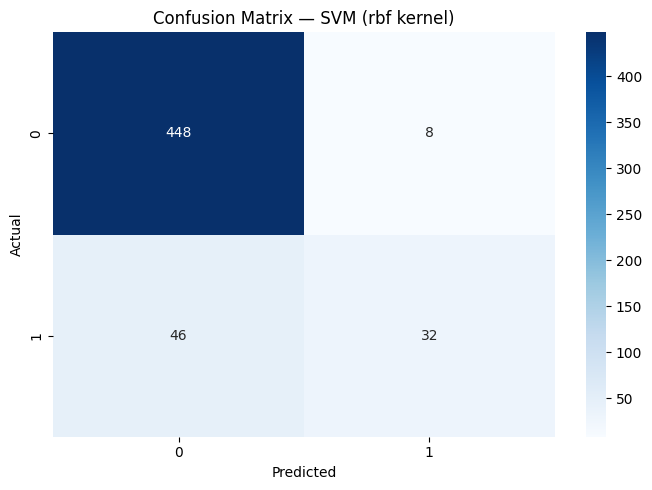

In [13]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — SVM ({best_kernel} kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 10: ROC Curve & AUC

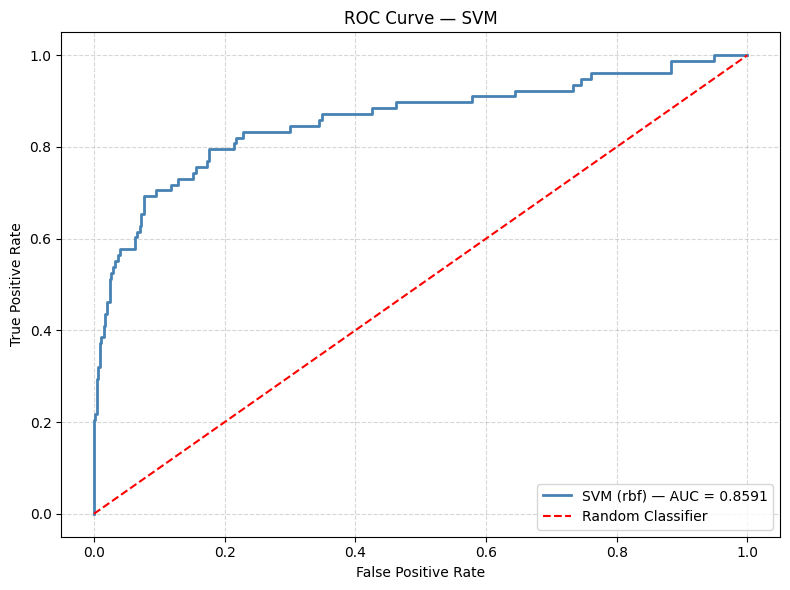

📌 AUC = 0.8591
  AUC close to 1.0 = excellent model
  AUC = 0.5 = random guessing


In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'SVM ({best_kernel}) — AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
plt.title('ROC Curve — SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'📌 AUC = {auc_score:.4f}')
print('  AUC close to 1.0 = excellent model')
print('  AUC = 0.5 = random guessing')

## Step 11: Visualize Decision Boundary (PCA 2D)

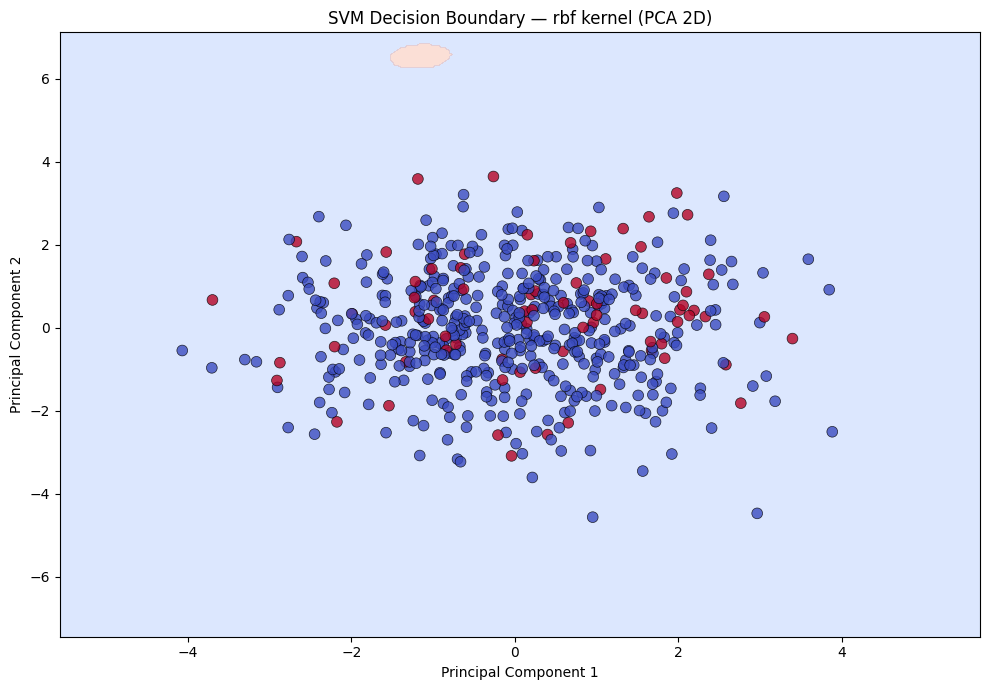

In [15]:
# Reduce to 2D with PCA for decision boundary visualization
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Train SVM on 2D data
svm_2d = SVC(kernel=best_kernel, random_state=42)
svm_2d.fit(X_train_2d, y_train)

# Create mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
            c=y_test, cmap='coolwarm', edgecolors='black',
            linewidths=0.5, alpha=0.8, s=60)
plt.title(f'SVM Decision Boundary — {best_kernel} kernel (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()